In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ, Matern
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp
from sklearn.gaussian_process.kernels import Kernel
from sklearn.model_selection import GridSearchCV

In [3]:
%run MLdata.ipynb
%run MLfunc.ipynb

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

# Gaussian Process Regressor (GPR) Model

In [4]:
class GPRmodel(GPR):
    def __init__(self, K, restarts, alpha, data=None):
        super(GPRmodel, self).__init__()
        self.K = self.set_K(K)
        self.res = restarts
        self.alpha = alpha
        
        self.GPR = self.build()
        if data:
            self.x = data[0]
            self.y = data[1]
            self.train()
    
    def set_K(self, K):
        return K
    
    def build(self):
        return GPR(kernel=self.K, n_restarts_optimizer=self.res, alpha=self.alpha)
    
    def train(self):
        self.GPR.fit(self.x, self.y)

        
def GPR_HPopt(data, gpr, params, cv=5, verb=0):
    grid_search = GridSearchCV(gpr, params, cv=cv, scoring="neg_mean_squared_error", verbose=verb)
    return grid_search.fit(data[0], data[1])

def plot_Kmatrix(gpr, x=None):
    if x is not None:
        K_pre = gpr.K(x)
        K_post = gpr.GPR.kernel_(x)
    else:
        K_pre = gpr.K(gpr.x)
        K_post = gpr.GPR.kernel_(gpr.x)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(K_pre, cmap='viridis', aspect='auto')
    ax1.set_title("Covariance Matrix Before Training")
    ax1.set_xlabel("Training Points")
    ax1.set_ylabel("Training Points")

    im2 = ax2.imshow(K_post, cmap='viridis', aspect='auto')
    ax2.set_title("Covariance Matrix After Training")
    ax2.set_xlabel("Training Points")
    ax2.set_ylabel("Training Points")

    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
    fig.colorbar(im2, cax=cbar_ax)

    plt.show()

In [5]:
def get_MeanStdCov(gpr, x, y):
    X_input = np.array([[x, y]])
    mean, std = gpr.GPR.predict(X_input, return_std=True)
    mean, cov = gpr.GPR.predict(X_input, return_cov=True)
    return mean[0][0], std[0], cov[0][0]

def Fsurface(gpr, density=50):
    x_values = np.linspace(-10, 130, density)
    y_values = np.linspace(-10, 170, density)
    X_grid, Y_grid = np.meshgrid(x_values, y_values)

    means2, stds2, covs2 = [], [], []
    for X_row, Y_row in zip(X_grid, Y_grid):
        means1, stds1, covs1 = [], [], []
        for x, y in zip(X_row, Y_row):
            mean, std, cov = get_MeanStdCov(gpr, x, y)
            means1.append(mean)
            stds1.append(std)
            covs1.append(cov)
        means2.append(means1)
        stds2.append(stds1)
        covs2.append(covs1)
    means2, stds2, covs2 = np.array(means2), np.array(stds2), np.array(covs2)
    return x_values, y_values, means2, stds2, covs2

def plot_Fsurface(x_values, y_values, val, typ="3d"):
    X_grid, Y_grid = np.meshgrid(x_values, y_values)
    if val.shape != X_grid.shape:
        val.reshape(X_grid.shape)
    
    if typ.lower() == "3d" or typ.lower() == "both":
        fig1 = plt.figure(figsize=(10, 6))
        ax = fig1.add_subplot(111, projection='3d')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.plot_surface(X_grid, Y_grid, val, cmap="viridis")
        
    if typ.lower() == "cont" or typ.lower() == "both":
        fig2 = plt.figure(figsize=(10, 6))
        ax = fig2.add_subplot(111)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        c = ax.contourf(X_grid, Y_grid, val, 50, cmap="viridis", vmin=np.min(val), vmax=np.max(val))
        fig2.colorbar(c)

    plt.show()

In [6]:
Ckernel1 = C()*Exp(length_scale=24, periodicity=1)
Ckernel2 = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
Ckernel3 = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

l, l_bounds = 1, (1e-9, 1e9)
a, a_bounds = 1, (1e-9, 1e9)
p, p_bounds = 1, (1e-9, 1e9)
kernel1 = RBF(length_scale=l, length_scale_bounds=l_bounds)  # C(length, (1e-3, 1e3)) * 
kernel2 = RQ(length_scale=l, alpha=a, length_scale_bounds=l_bounds, alpha_bounds=a_bounds)
kernel3 = Matern(length_scale=l, length_scale_bounds=l_bounds, nu=1.5)
kernel4 = Exp(length_scale=l, periodicity=p, length_scale_bounds=l_bounds, periodicity_bounds=p_bounds)
kernel5 = WhiteKernel(noise_level=1e-3)

kernels = [kernel1, kernel2, kernel3, kernel4, kernel5]
alphas = [1e-5, 1e-7, 1e-9]
params = {"kernel": kernels, "alpha": alphas}

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

In [7]:
gpr1 = GPRmodel(K=kernel1, restarts=5, alpha=0.3, data=[train_in1, dx_out1[1]])

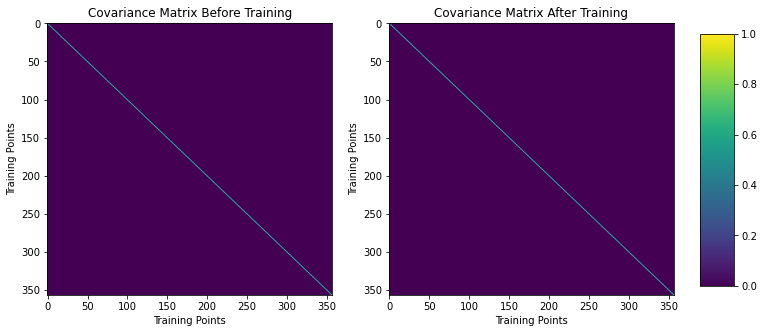

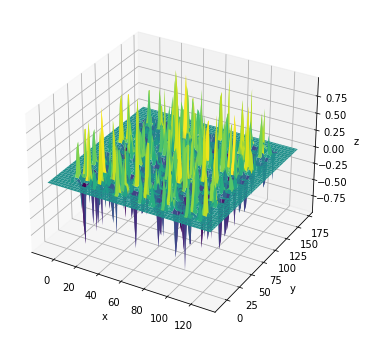

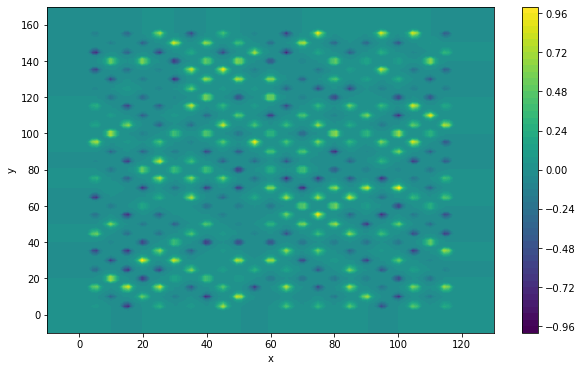

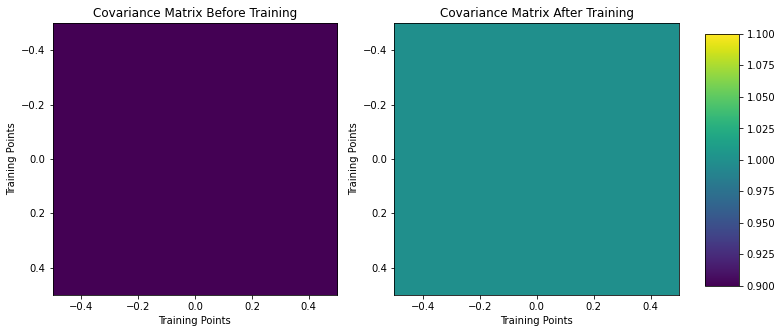

In [8]:
plot_Kmatrix(gpr1)
x_coords, y_coords, mean, std, cov = Fsurface(gpr=gpr1, density=100)
plot_Fsurface(x_coords, y_coords, mean, typ="both")
plot_Kmatrix(gpr1, x_coords)

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [12]:
gpr2 = GPRmodel(K=kernel1, restarts=5, alpha=0.3, data=[train_in[:500], train_out[:500]])
gpr2.fit(train_in, train_out)

y_mean, y_std = gpr2.predict(test_in, return_std=True)

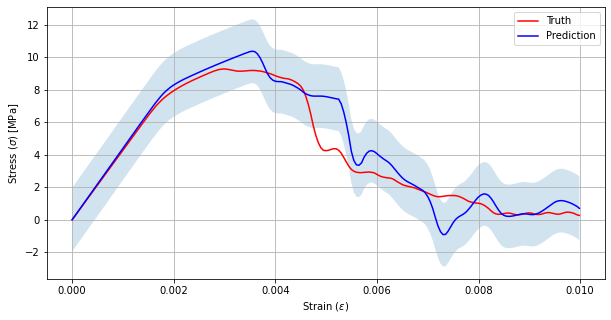

In [13]:
PLTidx = 1235

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(perOUT[0], test_out[0]+perOUT[1], 'r-', label="Truth")
plt.plot(perOUT[0], y_mean[PLTidx]+perOUT[1], 'b-', label="Prediction")
plt.fill_between(perOUT[0], y_mean[PLTidx]+perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()
